In [ ]:
#Step 1: Import Required Libraries
#Explain to students:
#Libraries are pre-written tools that help us perform data analysis and machine learning more easily.
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


In [ ]:
import numpy as np
np.random.seed(42)  # for reproducibility
n = 1000

In [ ]:
age = np.random.randint(20, 60, n)

income = np.random.randint(20000, 100000, n)

website_visits = np.random.randint(1, 15, n)

time_spent = np.random.randint(3, 35, n)

previous_purchases = np.random.randint(0, 6, n)

In [ ]:
purchase_score = (
    0.00005 * income +
    0.3 * website_visits +
    0.2 * time_spent +
    1.5 * previous_purchases
)

# Add some randomness (real-world noise)
noise = np.random.normal(0, 2, n)

final_score = purchase_score + noise

# Convert to 0/1 using threshold
purchased = (final_score > np.median(final_score)).astype(int)

In [ ]:
df = pd.DataFrame({
    "age": age,
    "income": income,
    "website_visits": website_visits,
    "time_spent": time_spent,
    "previous_purchases": previous_purchases,
    "purchased": purchased
})

In [ ]:
print(df.head())



   age  income  website_visits  time_spent  previous_purchases  purchased
0   58   64327               4          22                   2          0
1   48   88904               3          19                   5          0
2   34   23797              14          27                   4          1
3   27   67882              13          10                   1          0
4   40   33718               7          26                   2          1
(1000, 6)
purchased
0    500
1    500
Name: count, dtype: int64


In [ ]:
print(df.shape)

(1000, 6)


In [ ]:
print(df["purchased"].value_counts())

purchased
0    500
1    500
Name: count, dtype: int64


In [ ]:
# Step: Define Input Features (X) and Target Variable (y)

# In Machine Learning:
# X → Independent variables (features used for prediction)
# y → Dependent variable (target/output to predict)

# Input Features:
# These are the customer attributes the model will use to learn patterns
# age → Customer age
# income → Customer income
# website_visits → Number of visits to website
# time_spent → Time spent on website
# previous_purchases → Past purchase count

X = df[["age", "income", "website_visits", "time_spent", "previous_purchases"]]

# Target Variable:
# purchased → Whether the customer made a purchase (0 = No, 1 = Yes)

y = df["purchased"]


In [ ]:
# Step: Split the Data into Training and Testing Sets

# In Machine Learning:
# We never train and test on the same data.
# Reason: We want to evaluate how well the model performs on unseen data.

# Training Data:
# Used to teach the model patterns and relationships

# Testing Data:
# Used to evaluate model performance on new/unseen customers

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,        # 20% data used for testing, 80% for training
    random_state=42,      # Ensures reproducibility (same split every time)
    stratify=y            # Maintains class balance in train and test sets
)

# After split:
# X_train → Input features for training
# X_test  → Input features for testing
# y_train → Actual outputs for training
# y_test  → Actual outputs for testing

In [ ]:
from sklearn.preprocessing import StandardScaler

# Create scaler
scaler = StandardScaler()

# Fit ONLY on training data
X_train_scaled = scaler.fit_transform(X_train)

# Transform test data using same scaler
X_test_scaled = scaler.transform(X_test)

In [ ]:
# Step: Train the Machine Learning Model (Logistic Regression)

from sklearn.linear_model import LogisticRegression

# Create the model
# Logistic Regression is used for binary classification (0 or 1)
# max_iter increased to ensure proper convergence
model = LogisticRegression(max_iter=1000)

# Train (fit) the model
# IMPORTANT: Use scaled training data (X_train_scaled)
# The model learns patterns between input features and target variable
model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000)

In [ ]:
# Step: Make Predictions on Test Data

# model.predict() is used to generate predictions on unseen data

# IMPORTANT:
# Use scaled test data (X_test_scaled), not raw X_test
y_pred = model.predict(X_test_scaled)

# Display predicted values
y_pred

array([0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0,
       1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0,
       1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1,
       1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1,
       0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0,
       1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1,
       1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1,
       1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0,
       1, 1])

In [ ]:
# Step: Evaluate Model Performance using Accuracy

from sklearn.metrics import accuracy_score

# Accuracy measures how many predictions were correct
# Formula: (Correct Predictions) / (Total Predictions)

accuracy = accuracy_score(y_test, y_pred)

# Print accuracy
print("Accuracy:", accuracy)

Accuracy: 0.84


In [ ]:
# Step: Evaluate Model using Confusion Matrix

from sklearn.metrics import confusion_matrix

# Confusion Matrix compares actual values (y_test)
# with predicted values (y_pred)

cm = confusion_matrix(y_test, y_pred)

# Print the matrix
print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[86 14]
 [18 82]]


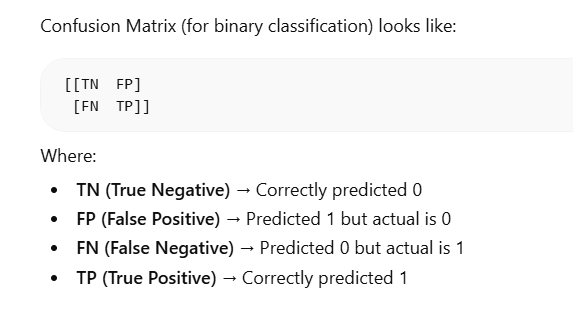

In [ ]:
# Step: Generate Classification Report

from sklearn.metrics import classification_report

# Classification Report provides detailed performance metrics
# It includes:
# Precision → How many predicted positives are correct
# Recall → How many actual positives are correctly identified
# F1-score → Balance between Precision and Recall
# Support → Number of actual samples in each class

print("Classification Report:")
print(classification_report(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.86      0.84       100
           1       0.85      0.82      0.84       100

    accuracy                           0.84       200
   macro avg       0.84      0.84      0.84       200
weighted avg       0.84      0.84      0.84       200



In [ ]:
import pandas as pd

# Create DataFrame with SAME column names
new_customer_df = pd.DataFrame(
    [[35, 55000, 7, 18, 2]],
    columns=["age", "income", "website_visits", "time_spent", "previous_purchases"]
)

# Scale
new_customer_scaled = scaler.transform(new_customer_df)

# Predict
prediction = model.predict(new_customer_scaled)

print("Prediction:", prediction)

Prediction: [0]


In [ ]:
new_customer_df = pd.DataFrame(
    [[45, 80000, 12, 28, 4]],
    columns=["age", "income", "website_visits", "time_spent", "previous_purchases"]
)

new_customer_scaled = scaler.transform(new_customer_df)
prediction = model.predict(new_customer_scaled)

print("Prediction:", prediction)

Prediction: [1]
